# Machine Learning – Classification Part A
## Water Quality Classification

### Problem Definition

The aim of this project is to classify water samples into three water-quality classes: **Good, Moderate, and Poor**.

We use the measurements available in the dataset to train different machine learning classification models. The five required models are compared using common classification metrics.

The original dataset contains **80,000 rows**. We keep the available data for the modelling workflow and do not take a small random sample.

## 1. Import Libraries

We first import the Python libraries needed for this project.

- **Pandas and NumPy** are used to work with the dataset.
- **Matplotlib and Seaborn** are used for visualizations.
- **Scikit-learn** is used for preprocessing, classification models, tuning, and evaluation.
- **Joblib** is used to save the final trained model.

Only the libraries needed for this classification task are included.

In [1]:
import os
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder, label_binarize
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, roc_curve, classification_report
)

warnings.filterwarnings("ignore")
RANDOM_STATE = 42


## 2. Load Dataset — Original 80,000 Rows — Original 80,000 Rows

The original water-quality dataset is loaded here.

We use the complete dataset rather than taking a smaller modelling sample. At this stage, we only load the data; cleaning and preprocessing are done in the following sections.

This helps us keep the original data separate from the later modelling steps.

In [2]:
DATA_PATH = "C:\\Users\\ravin\\OneDrive\\Desktop\\ML Project\\Classification\\water_quality_classification_dataset.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
print("Original number of rows:", len(df))
display(df.head())

Dataset shape: (80000, 53)
Original number of rows: 80000


,Sample Date,Sample Time,Depth,total_phosphorus,pH,temperature,dissolved_reactive_phosphorus,total_dissolved_phosphorus,electrical_conductance,nitrate_nitrogen,...,fluoride,strontium,lithium,sulfate,total_solids,ammonium_nitrogen,oxidized_nitrogen,nickel,ammonia_nitrogen,Water_Quality_Class
0,2016-04-01,12:00,0.3,0.809007,8.10,27.5,NaN,NaN,1613.0,9.679672,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0068,1.2597,Poor
1,2001-03-06,12:00,0.3,NaN,4.72,7.9,NaN,NaN,1003.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Poor
2,2019-01-24,NaN,14.0,NaN,NaN,24.7,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2022-01-01,NaN,1.0,NaN,NaN,NaN,NaN,NaN,638.0,8.939066,...,NaN,NaN,NaN,NaN,NaN,0.007765,NaN,NaN,NaN,Moderate
4,2014-10-01,NaN,0.3,NaN,NaN,NaN,NaN,NaN,471.0,17.381518,...,NaN,NaN,NaN,NaN,NaN,0.007765,NaN,NaN,NaN,Moderate


## 3. Dataset Audit

Before making any changes to the data, we first understand what is inside it.

We check:

- the number of rows and columns,
- the data types,
- the number of missing values,
- and the distribution of the target classes.

This gives us a clear picture of the dataset and helps us decide what cleaning and preprocessing are needed.

In [3]:
TARGET = "Water_Quality_Class"

print("Shape:", df.shape)
print("\nData types:")
display(df.dtypes)

print("\nMissing values by column:")
missing_values = df.isnull().sum().sort_values(ascending=False)
display(missing_values[missing_values > 0])

print("\nTarget distribution:")
display(df[TARGET].value_counts())

Shape: (80000, 53)

Data types:


Sample Date                       object
Sample Time                       object
Depth                            float64
total_phosphorus                 float64
pH                               float64
temperature                      float64
dissolved_reactive_phosphorus    float64
total_dissolved_phosphorus       float64
electrical_conductance           float64
nitrate_nitrogen                 float64
dissolved_oxygen                 float64
nitrite_nitrogen                 float64
oxygen_saturation                float64
hardness                         float64
biochemical_oxygen_demand        float64
total_suspended_solids           float64
bicarbonate                      float64
dissolved_organic_carbon         float64
chloride                         float64
total_organic_carbon             float64
chemical_oxygen_demand           float64
cadmium                          float64
lead                             float64
chromium                         float64
total_dissolved_


Missing values by column:


total_solids                     79365
sulfate                          78858
lithium                          77440
strontium                        77302
fluoride                         76819
uranium                          76334
boron                            76270
selenium                         76108
barium                           75905
silica                           75889
cobalt                           75393
total_dissolved_phosphorus       74956
dissolved_reactive_phosphorus    74488
manganese                        72870
copper                           72430
iron                             72290
zinc                             71972
potassium                        69522
ammonia_nitrogen                 69101
alkalinity                       68734
sodium                           68459
mercury                          68270
magnesium                        67980
turbidity                        67036
calcium                          66967
arsenic                  


Target distribution:


Water_Quality_Class
Moderate    39550
Good        15651
Poor        12687
Name: count, dtype: int64

### Initial Observation

The target variable has three classes: **Good, Moderate, and Poor**.

The missing-value check also shows that some measurements are incomplete. We will handle these missing values later using a method learned from the training data.

At this stage, no model-related preprocessing is performed.

## 4. Exploratory Data Analysis (EDA)

EDA helps us understand the water-quality measurements before training the models.

In this section, we look at:

1. the distribution of the numeric features,
2. the distribution of the three target classes,
3. the correlation between numeric features,
4. and relationships between selected features and the target.

The goal is to understand the data, not to make the final model decision from the plots.

In [4]:
print("Duplicate rows before removal:", df.duplicated().sum())
df = df.drop_duplicates().reset_index(drop=True)

target_missing = df[TARGET].isna().sum()
print("Missing target values:", target_missing)
if target_missing > 0:
    df = df.dropna(subset=[TARGET]).reset_index(drop=True)

print("Shape after cleaning:", df.shape)
print("Duplicate rows after cleaning:", df.duplicated().sum())

Duplicate rows before removal: 116
Missing target values: 12011
Shape after cleaning: (67873, 53)
Duplicate rows after cleaning: 0


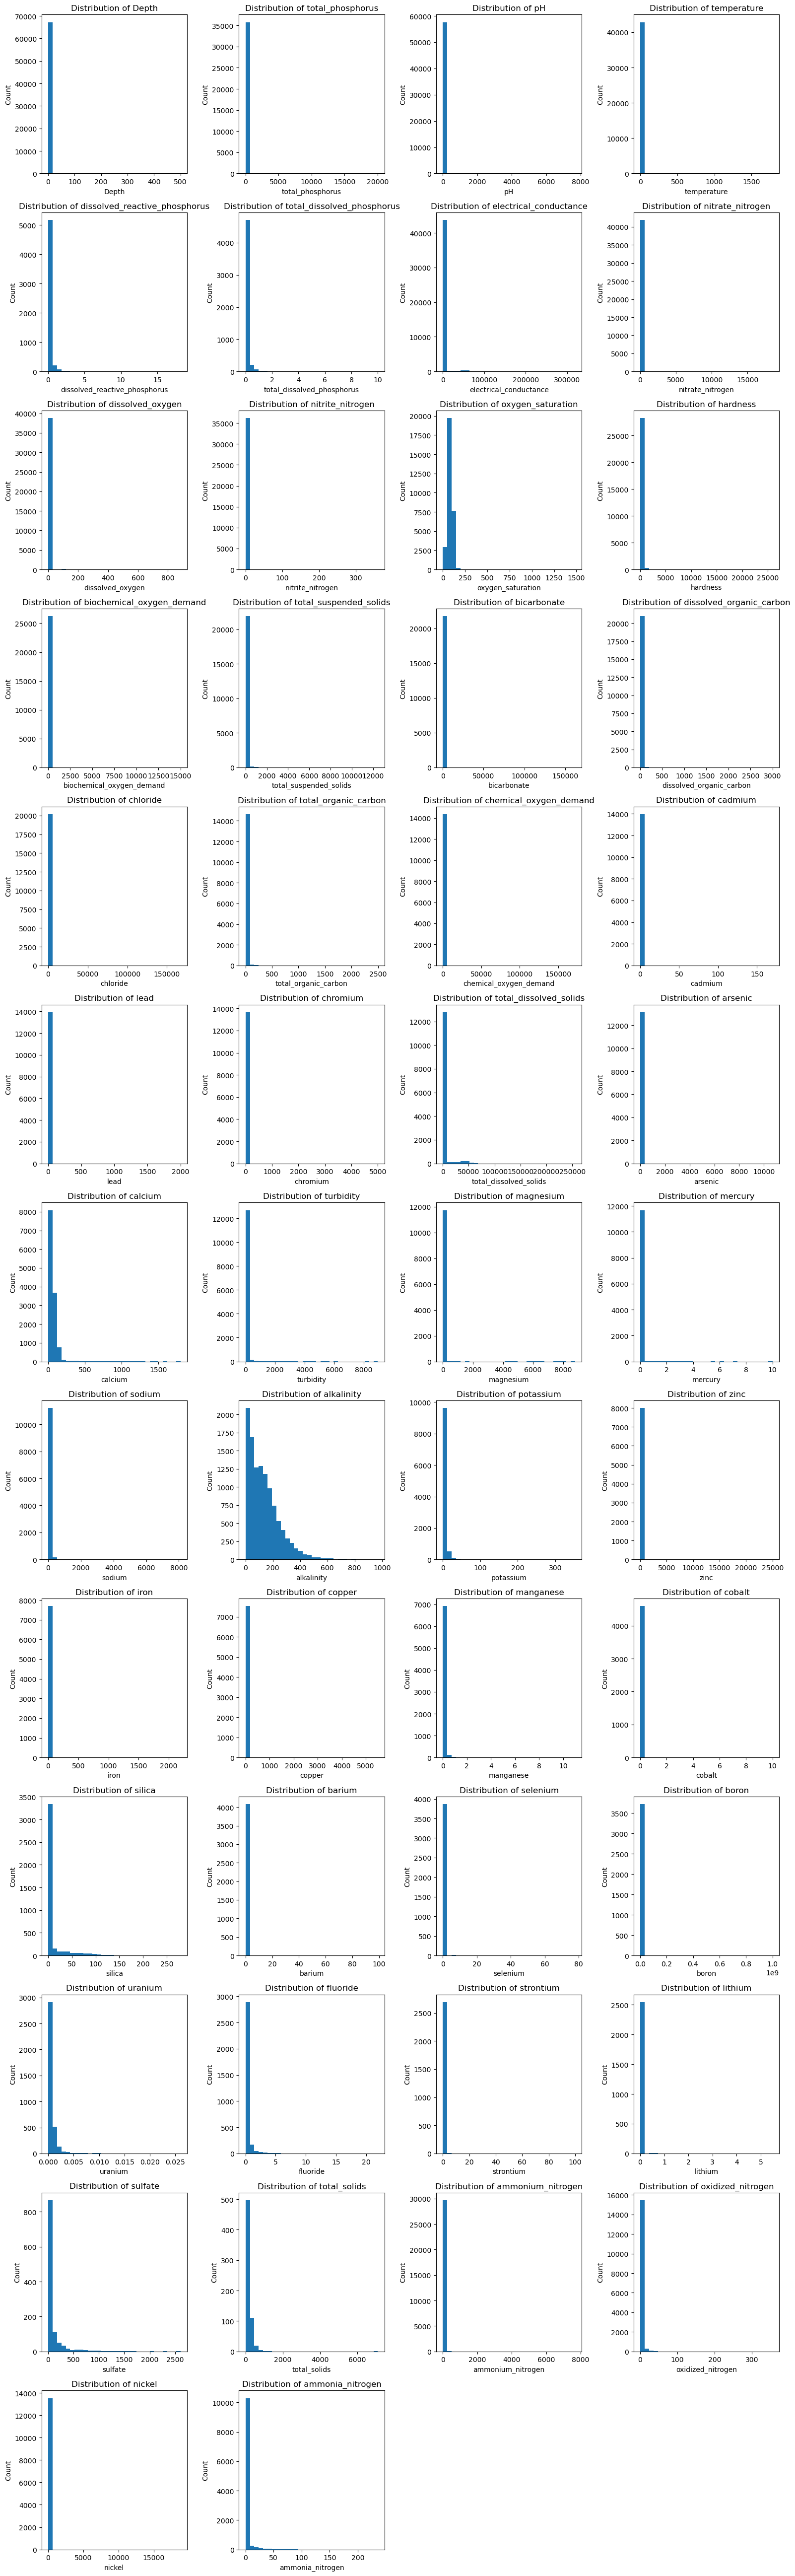

In [5]:
numeric_columns = df.select_dtypes(include=np.number).columns.tolist()

# Distribution plot for every numeric feature
n_cols = 4
n_rows = int(np.ceil(len(numeric_columns) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = np.array(axes).reshape(-1)

for i, col in enumerate(numeric_columns):
    values = df[col].dropna()
    axes[i].hist(values, bins=30)
    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")

for j in range(len(numeric_columns), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()


### EDA Observation — Feature Distributions

The features have different ranges and some of them contain missing values.

The different ranges are one reason why scaling will be useful, especially for distance- and boundary-based models such as KNN and SVM. Missing values will be handled after the train/test split so that information from the test set is not used during preprocessing.

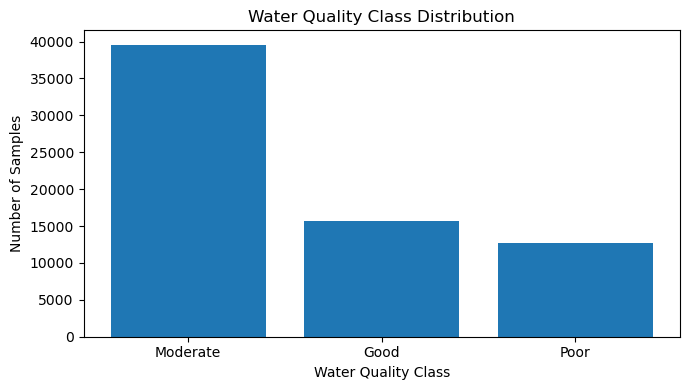

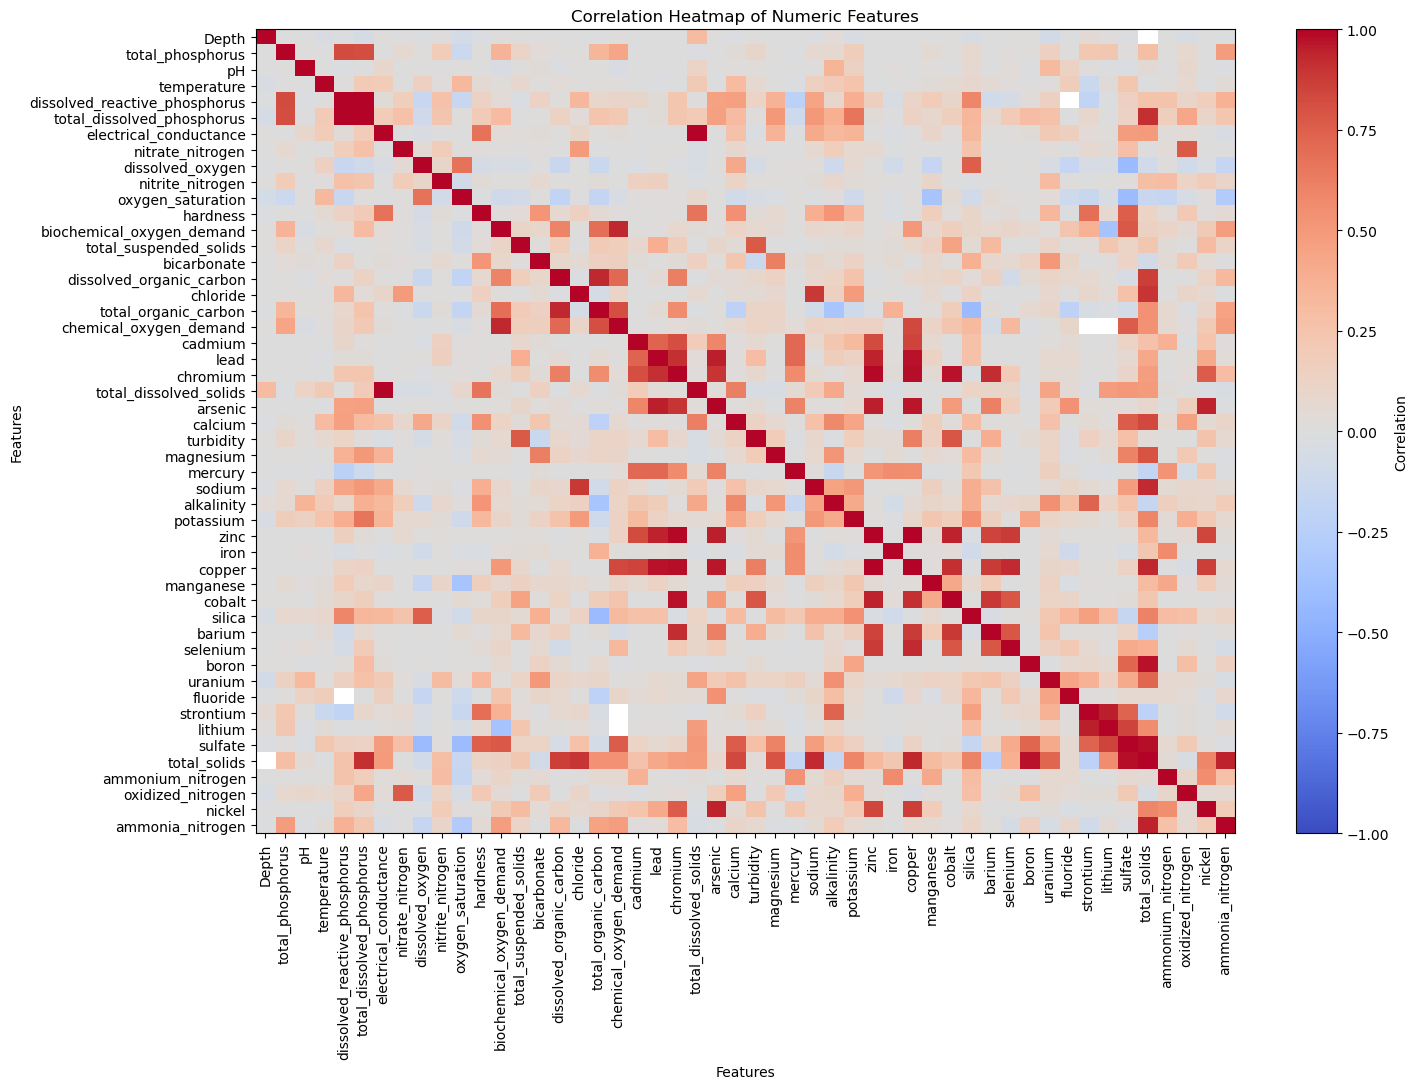

In [6]:
# Target distribution
counts = df[TARGET].value_counts()
plt.figure(figsize=(7, 4))
plt.bar(counts.index, counts.values)
plt.title("Water Quality Class Distribution")
plt.xlabel("Water Quality Class")
plt.ylabel("Number of Samples")
plt.tight_layout()
plt.show()

# Correlation heatmap
plt.figure(figsize=(15, 11))
corr = df[numeric_columns].corr()
plt.imshow(corr, aspect="auto", cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Correlation")
plt.xticks(range(len(numeric_columns)), numeric_columns, rotation=90)
plt.yticks(range(len(numeric_columns)), numeric_columns)
plt.title("Correlation Heatmap of Numeric Features")
plt.xlabel("Features")
plt.ylabel("Features")
plt.tight_layout()
plt.show()


### EDA Observation — Target Distribution and Correlation

The target distribution shows how many samples belong to each water-quality class.

The correlation heatmap helps us see relationships between the numeric measurements. Some features show stronger relationships with each other, while others have weaker relationships. These relationships are useful to understand before building the classifiers.

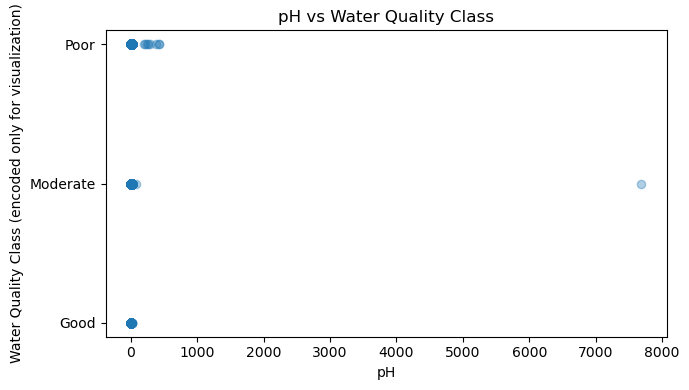

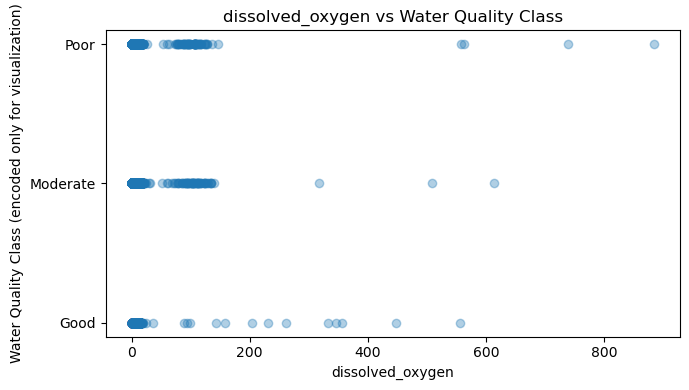

In [7]:
# Feature → target scatter plots
# The target is encoded only for visualization, not used as a model input.
plot_target = df[TARGET].map({"Good": 0, "Moderate": 1, "Poor": 2})

for feature in ["pH", "dissolved_oxygen"]:
    plot_df = pd.DataFrame({feature: df[feature], "Class Code": plot_target}).dropna()
    plt.figure(figsize=(7, 4))
    plt.scatter(plot_df[feature], plot_df["Class Code"], alpha=0.35)
    plt.title(f"{feature} vs Water Quality Class")
    plt.xlabel(feature)
    plt.ylabel("Water Quality Class (encoded only for visualization)")
    plt.yticks([0, 1, 2], ["Good", "Moderate", "Poor"])
    plt.tight_layout()
    plt.show()


### EDA Observation — Feature and Target Relationship

The scatter plots show how **pH** and **dissolved oxygen** vary across the three water-quality classes.

Because the target is categorical, its classes are given temporary numeric values only for drawing these plots. This visual encoding is **not used as a model input**.

## 5. Duplicate Check and Basic Cleaning

Duplicate rows can give repeated information to a model, so we check for exact duplicates and remove them when they are present.

We also remove rows where the target class is missing because a supervised classification model needs a known target value for training.

No feature values are filled manually here. Feature missing values are handled later through the preprocessing pipeline.

## 6. Feature Engineering

Feature engineering means creating useful information from the existing columns.

Here, we create simple date-based features from the sample date, such as year, month, and day of the year. We also create a **solids-to-conductivity ratio** to represent the relationship between these two measurements.

These features are created without using the target, so the target does not influence the engineered features.

In [8]:
# Date-based features
sample_date = pd.to_datetime(df["Sample Date"], errors="coerce")
df["sample_year"] = sample_date.dt.year
df["sample_month"] = sample_date.dt.month
df["sample_dayofyear"] = sample_date.dt.dayofyear

# Useful ratio feature
denominator = df["electrical_conductance"].replace(0, np.nan)
df["solids_conductivity_ratio"] = df["total_solids"] / denominator

# The raw date/time text is not used by the classifiers.
df = df.drop(columns=["Sample Date", "Sample Time"])

print("Feature engineering completed.")
print("New features: sample_year, sample_month, sample_dayofyear, solids_conductivity_ratio")

Feature engineering completed.
New features: sample_year, sample_month, sample_dayofyear, solids_conductivity_ratio


## 7. Train/Test Split — Stratified 80:20

Before applying model preprocessing, we divide the cleaned data into training and testing sets.

We use an **80:20 split** and stratify by the target class. Stratification helps keep the proportions of Good, Moderate, and Poor samples similar in both sets.

The same split is used for all five classification algorithms so that their results can be compared fairly.

In [9]:
X = df.drop(columns=[TARGET]).copy()
y = df[TARGET].copy()

# Keep the numeric predictors for the five classifiers.
X = X.select_dtypes(include=np.number)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("All modelling rows:", len(X))
print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))
print("Training class proportions:")
display(y_train.value_counts(normalize=True).rename("Proportion"))

All modelling rows: 67873
Training rows: 54298
Testing rows: 13575
Training class proportions:


Water_Quality_Class
Moderate    0.582618
Good        0.230487
Poor        0.186895
Name: Proportion, dtype: float64

## 8. Missing Value Handling

Some water-quality measurements contain missing values.

We use **median imputation** for numeric features. The median is calculated using only the training data and then applied to both the training and test data.

This prevents information from the test set from being used to learn the preprocessing values.

## 9. IQR Outlier Handling

Some measurements may contain unusually high or low values.

Instead of deleting those rows, we use the **Interquartile Range (IQR)** method to cap extreme values. The IQR limits are learned from the training data only.

This keeps the samples in the dataset while reducing the effect of extreme observations.

## 10. Standard Scaling

The features have different units and ranges, so we standardize them using **StandardScaler**.

The scaler is fitted only on the training data and then applied to the test data.

Scaling is particularly important for **KNN and SVM**, because these algorithms are affected by the scale of the input features. Keeping the same preprocessing also makes the comparison between models consistent.

In [10]:
class IQRCapper(BaseEstimator, TransformerMixin):
    """Cap numeric values using IQR limits learned from the training data."""
    def fit(self, X, y=None):
        X_df = pd.DataFrame(X)
        q1 = X_df.quantile(0.25)
        q3 = X_df.quantile(0.75)
        iqr = q3 - q1
        self.lower_ = (q1 - 1.5 * iqr).to_numpy()
        self.upper_ = (q3 + 1.5 * iqr).to_numpy()
        return self

    def transform(self, X):
        X_arr = np.asarray(X, dtype=float)
        return np.clip(X_arr, self.lower_, self.upper_)

preprocessor = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("iqr_capper", IQRCapper()),
    ("scaler", StandardScaler())
])

print("Preprocessing pipeline created: median imputation → IQR capping → standard scaling")

Preprocessing pipeline created: median imputation → IQR capping → standard scaling


## 11. Target Encoding

The target contains the class names **Good, Moderate, and Poor**.

For model training and some metric calculations, these class names are converted into numeric labels. The original class names are still used when displaying results and confusion matrices.

This encoding is only for the target variable; it does not create an input feature.

In [11]:
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)
class_names = label_encoder.classes_

print("Class mapping:")
for i, name in enumerate(class_names):
    print(f"{name} -> {i}")

Class mapping:
Good -> 0
Moderate -> 1
Poor -> 2


# Algorithm 1 — Logistic Regression

### Purpose

Logistic Regression is used as the baseline classification model.

It provides a simple reference point that we can compare with the other algorithms. The model is trained on the preprocessed training data and then used to predict the water-quality class of the test samples.

In [12]:
logistic_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])
logistic_model.fit(X_train, y_train_encoded)
logistic_pred = logistic_model.predict(X_test)
logistic_score = logistic_model.predict_proba(X_test)
print("Logistic Regression trained successfully.")

Logistic Regression trained successfully.


# Algorithm 2 — K-Nearest Neighbors (KNN)

### Purpose

KNN predicts the class of a sample by looking at nearby training samples.

Because KNN uses distances, feature scaling is important. We also tune the value of **k**, which controls how many nearby samples are considered when making a prediction.

In [13]:
knn_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", KNeighborsClassifier(n_neighbors=5, n_jobs=-1))
])
knn_model.fit(X_train, y_train_encoded)
knn_pred = knn_model.predict(X_test)
knn_score = knn_model.predict_proba(X_test)
print("KNN trained successfully.")

KNN trained successfully.


# Algorithm 3 — Gaussian Naive Bayes

### Purpose

Gaussian Naive Bayes is a probability-based classification model.

It assumes that the features are conditionally independent given the class. This is a simplified assumption, but the model is fast and gives us another useful comparison with the other classifiers.

In [14]:
nb_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", GaussianNB())
])
nb_model.fit(X_train, y_train_encoded)
nb_pred = nb_model.predict(X_test)
nb_score = nb_model.predict_proba(X_test)
print("Gaussian Naive Bayes trained successfully.")

Gaussian Naive Bayes trained successfully.


# Algorithm 4 — Decision Tree Classifier

### Purpose

A Decision Tree classifies a sample by making a series of decisions based on feature values.

We tune **max_depth** and other tree settings to control the complexity of the tree and reduce the chance of overfitting. The tree can also be visualized and its feature importance can be inspected later.

In [15]:
dt_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(random_state=RANDOM_STATE, max_depth=None))
])
dt_model.fit(X_train, y_train_encoded)
dt_pred = dt_model.predict(X_test)
dt_score = dt_model.predict_proba(X_test)
print("Decision Tree trained successfully.")

Decision Tree trained successfully.


# Algorithm 5 — Support Vector Machine (SVM/SVC)

### Purpose

SVM tries to find a decision boundary that separates the classes.

Feature scaling is important because the position of this boundary is affected by feature magnitude. We tune **C** and the **kernel** later to see which settings work better for the classification task.

In [16]:
svm_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", SVC(kernel="linear", C=1.0, probability=False, random_state=RANDOM_STATE, max_iter=1000))
])
svm_model.fit(X_train, y_train_encoded)
svm_pred = svm_model.predict(X_test)
svm_score = svm_model.decision_function(X_test)
print("SVM trained successfully.")


SVM trained successfully.


## 12. Initial Evaluation

After training the five required algorithms, we first evaluate their predictions on the same test set.

The main metrics are:

- **Accuracy**
- **Precision**
- **Recall**
- **Weighted F1-score**

These give us different views of model performance. The test set remains separate from the hyperparameter tuning process.

In [17]:
models_predictions = {
    "Logistic Regression": (logistic_pred, logistic_score),
    "KNN": (knn_pred, knn_score),
    "Gaussian Naive Bayes": (nb_pred, nb_score),
    "Decision Tree": (dt_pred, dt_score),
    "SVM": (svm_pred, svm_score)
}

def multiclass_auc(y_true, score):
    # Probability outputs are used directly; SVM uses decision scores.
    if score.ndim == 2 and np.allclose(score.sum(axis=1), 1.0, atol=1e-6):
        return roc_auc_score(y_true, score, multi_class="ovr", average="weighted")
    y_bin = label_binarize(y_true, classes=np.arange(len(class_names)))
    return roc_auc_score(y_bin, score, average="weighted")

results = []
for name, (pred, score) in models_predictions.items():
    results.append({
        "Algorithm": name,
        "Accuracy": accuracy_score(y_test_encoded, pred),
        "Precision": precision_score(y_test_encoded, pred, average="weighted", zero_division=0),
        "Recall": recall_score(y_test_encoded, pred, average="weighted", zero_division=0),
        "Weighted F1": f1_score(y_test_encoded, pred, average="weighted"),
        "ROC-AUC": multiclass_auc(y_test_encoded, score)
    })

results_df = pd.DataFrame(results)
display(results_df.style.format({c: "{:.4f}" for c in results_df.columns if c != "Algorithm"}))


,Algorithm,Accuracy,Precision,Recall,Weighted F1,ROC-AUC
0,Logistic Regression,0.6767,0.6705,0.6767,0.6600,0.7833
1,KNN,0.7497,0.7477,0.7497,0.7483,0.8480
2,Gaussian Naive Bayes,0.6703,0.6632,0.6703,0.6637,0.7824
3,Decision Tree,0.7184,0.7186,0.7184,0.7185,0.7455
4,SVM,0.3758,0.4686,0.3758,0.3857,0.5588


## 13. Confusion Matrices

A confusion matrix shows the actual class against the predicted class.

It helps us see not only how many predictions were correct, but also which classes are being confused with one another.

Since this is a three-class problem, the matrix contains results for **Good, Moderate, and Poor**.

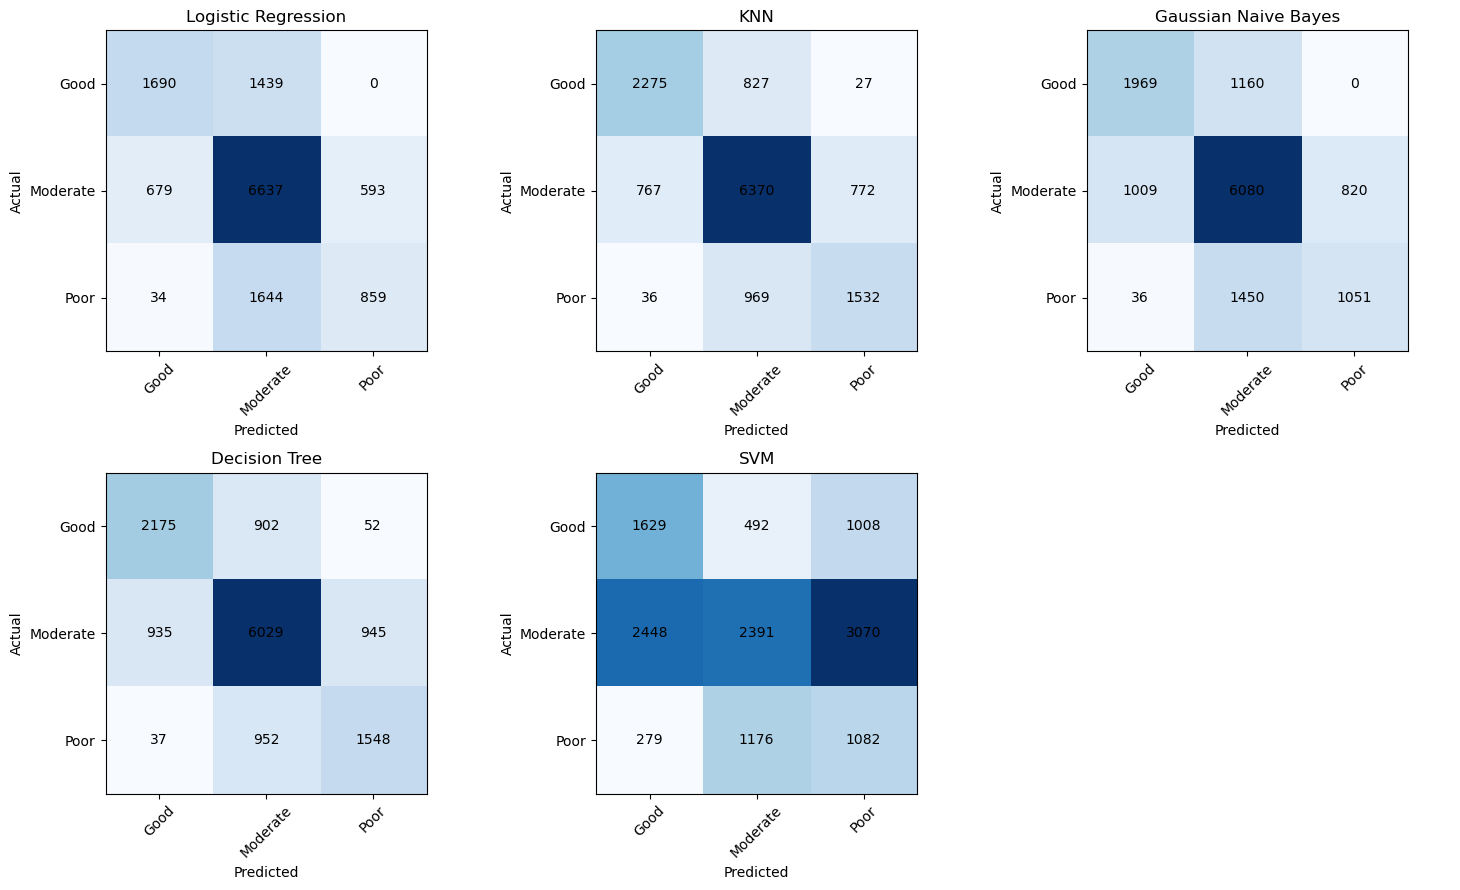

In [18]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.ravel()
for i, (name, (pred, _)) in enumerate(models_predictions.items()):
    cm = confusion_matrix(y_test_encoded, pred)
    axes[i].imshow(cm, cmap="Blues")
    for r in range(cm.shape[0]):
        for col in range(cm.shape[1]):
            axes[i].text(col, r, str(cm[r, col]), ha="center", va="center")
    axes[i].set_title(name)
    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("Actual")
    axes[i].set_xticks(range(len(class_names)), class_names, rotation=45)
    axes[i].set_yticks(range(len(class_names)), class_names)
axes[-1].axis("off")
plt.tight_layout()
plt.show()


## 14. Multiclass ROC-AUC

This project has three target classes, so ROC-AUC is calculated using the **One-vs-Rest (OvR)** approach.

In OvR, each class is considered against all the other classes. The resulting ROC-AUC values are combined to give a multiclass measure of how well the model separates the classes.

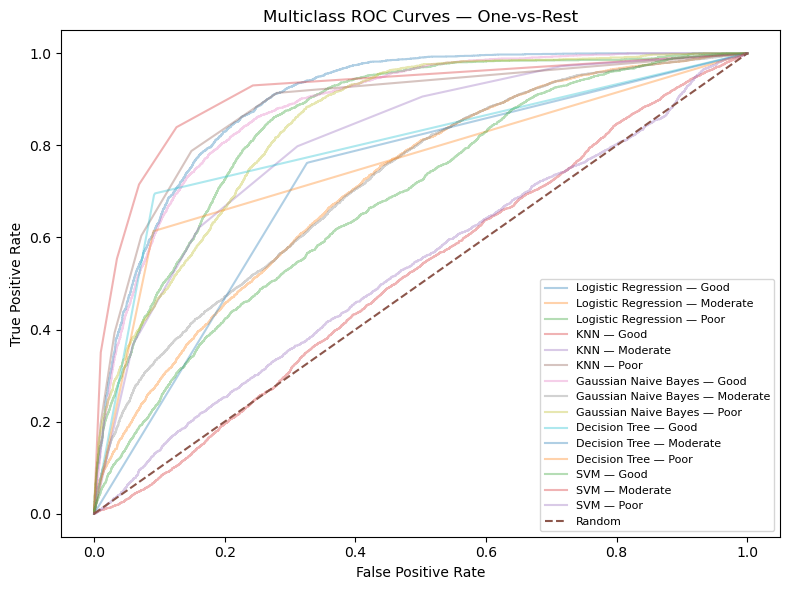

In [19]:
y_test_bin = label_binarize(y_test_encoded, classes=np.arange(len(class_names)))

plt.figure(figsize=(8, 6))
for name, (_, score) in models_predictions.items():
    for i in range(len(class_names)):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], score[:, i])
        plt.plot(fpr, tpr, alpha=0.35, label=f"{name} — {class_names[i]}")

plt.plot([0, 1], [0, 1], linestyle="--", label="Random")
plt.title("Multiclass ROC Curves — One-vs-Rest")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()


In [20]:
# Release large fitted baseline objects before cross-validated tuning.
# The predictions and scores needed for evaluation are already stored above.
del knn_model, svm_model


## 15. GridSearchCV

GridSearchCV is used to find better hyperparameter settings for selected models.

The search is performed using the **training data only**. We keep the parameter grids reasonably small so that the notebook remains practical while still testing meaningful alternatives.

The main tuning examples are:

- **KNN:** number of neighbours
- **Decision Tree:** tree depth and split settings
- **SVM:** C and kernel

In [21]:
cv3 = StratifiedKFold(n_splits=2, shuffle=True, random_state=RANDOM_STATE)

logistic_grid = {
    "model__C": [0.1, 1.0]
}

logistic_search = GridSearchCV(
    Pipeline([
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
    ]),
    logistic_grid,
    cv=cv3,
    scoring="f1_weighted",
    n_jobs=1,
    pre_dispatch=1
)

logistic_search.fit(X_train, y_train_encoded)
print("Best Logistic Regression parameters:", logistic_search.best_params_)

Best Logistic Regression parameters: {'model__C': 1.0}


In [22]:
dt_grid = {
    "model__max_depth": [10, 20],
    "model__min_samples_split": [2, 5]
}

dt_search = GridSearchCV(
    Pipeline([
        ("preprocessor", preprocessor),
        ("model", DecisionTreeClassifier(random_state=RANDOM_STATE))
    ]),
    dt_grid,
    cv=cv3,
    scoring="f1_weighted",
    n_jobs=1,
    pre_dispatch=1
)

dt_search.fit(X_train, y_train_encoded)
print("Best Decision Tree parameters:", dt_search.best_params_)

Best Decision Tree parameters: {'model__max_depth': 10, 'model__min_samples_split': 5}


### Tuning Note

Only selected models are tuned with GridSearchCV so that the notebook stays practical on the full dataset.

The required five algorithms are still trained and evaluated. Hyperparameter tuning is used where it gives a useful improvement without making the project unnecessarily complicated.

In [23]:
tuned_logistic = logistic_search.best_estimator_
tuned_dt = dt_search.best_estimator_

tuned_models = {
    "Tuned Logistic Regression": tuned_logistic,
    "Tuned Decision Tree": tuned_dt
}

tuned_results = []
for name, model in tuned_models.items():
    pred = model.predict(X_test)
    score = model.predict_proba(X_test)
    tuned_results.append({
        "Algorithm": name,
        "Accuracy": accuracy_score(y_test_encoded, pred),
        "Precision": precision_score(y_test_encoded, pred, average="weighted", zero_division=0),
        "Recall": recall_score(y_test_encoded, pred, average="weighted", zero_division=0),
        "Weighted F1": f1_score(y_test_encoded, pred, average="weighted"),
        "ROC-AUC": multiclass_auc(y_test_encoded, score)
    })

tuned_results_df = pd.DataFrame(tuned_results)
display(tuned_results_df.style.format({c: "{:.4f}" for c in tuned_results_df.columns if c != "Algorithm"}))

,Algorithm,Accuracy,Precision,Recall,Weighted F1,ROC-AUC
0,Tuned Logistic Regression,0.6767,0.6705,0.6767,0.6600,0.7833
1,Tuned Decision Tree,0.7552,0.7548,0.7552,0.7549,0.8626


## 17. 5-Fold Cross-Validation

Cross-validation gives a more reliable view of model performance on the training data.

We use **5 folds** and keep the test set completely separate. The preprocessing steps are included in the model pipeline so that each fold learns its preprocessing values only from its own training portion.

The main score used for comparison is **weighted F1-score**.

In [24]:
# Use only training/CV results for model selection.
tuned_cv_scores = {
    "Tuned Logistic Regression": logistic_search.best_score_,
    "Tuned Decision Tree": dt_search.best_score_
}

model_lookup = {
    "Tuned Logistic Regression": tuned_logistic,
    "Tuned Decision Tree": tuned_dt
}

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_rows = []

for name in model_lookup:
    scores = cross_val_score(
        model_lookup[name],
        X_train,
        y_train_encoded,
        cv=cv5,
        scoring="f1_weighted",
        n_jobs=1
    )
    cv_rows.append({
        "Algorithm": name,
        "GridSearchCV Best F1": tuned_cv_scores[name],
        "Mean 5-Fold Weighted F1": scores.mean(),
        "Std 5-Fold Weighted F1": scores.std()
    })

cv_results_df = pd.DataFrame(cv_rows)
display(cv_results_df.style.format({
    "GridSearchCV Best F1": "{:.4f}",
    "Mean 5-Fold Weighted F1": "{:.4f}",
    "Std 5-Fold Weighted F1": "{:.4f}"
}))

,Algorithm,GridSearchCV Best F1,Mean 5-Fold Weighted F1,Std 5-Fold Weighted F1
0,Tuned Logistic Regression,0.6638,0.6639,0.0045
1,Tuned Decision Tree,0.7438,0.7495,0.0047


## 18. Model Comparison

The five required algorithms and the tuned models are compared using the same test set.

The table contains the main evaluation metrics so that the results are easy to compare in one place.

The test results are reported for evaluation. They are not used to tune the models or decide the final model.

In [25]:
comparison_df = pd.concat([results_df, tuned_results_df], ignore_index=True)
display(comparison_df.sort_values("Weighted F1", ascending=False).reset_index(drop=True).style.format({c: "{:.4f}" for c in comparison_df.columns if c != "Algorithm"}))

,Algorithm,Accuracy,Precision,Recall,Weighted F1,ROC-AUC
0,Tuned Decision Tree,0.7552,0.7548,0.7552,0.7549,0.8626
1,KNN,0.7497,0.7477,0.7497,0.7483,0.8480
2,Decision Tree,0.7184,0.7186,0.7184,0.7185,0.7455
3,Gaussian Naive Bayes,0.6703,0.6632,0.6703,0.6637,0.7824
4,Logistic Regression,0.6767,0.6705,0.6767,0.6600,0.7833
5,Tuned Logistic Regression,0.6767,0.6705,0.6767,0.6600,0.7833
6,SVM,0.3758,0.4686,0.3758,0.3857,0.5588


## 19. Final Model

The final model is selected using the **mean 5-fold weighted F1-score from the training data**.

This keeps the test set untouched during model selection. After the final model is chosen, its performance on the test set can be reported as the final evaluation.

In [26]:
final_name = cv_results_df.sort_values(
    "Mean 5-Fold Weighted F1", ascending=False
).iloc[0]["Algorithm"]
final_model = model_lookup[final_name]

final_pred = final_model.predict(X_test)
print("Final model selected using training 5-fold CV:", final_name)
print("Final test Accuracy:", f"{accuracy_score(y_test_encoded, final_pred):.4f}")
print("Final test Weighted F1:", f"{f1_score(y_test_encoded, final_pred, average='weighted'):.4f}")

Final model selected using training 5-fold CV: Tuned Decision Tree
Final test Accuracy: 0.7552
Final test Weighted F1: 0.7549


## 20. Decision Tree Interpretation

The Decision Tree can be understood by looking at its feature importance values.

Feature importance gives an indication of which measurements contributed more to the tree's decisions. The tree visualization also helps us see how the model makes a sequence of decisions to classify a water sample.

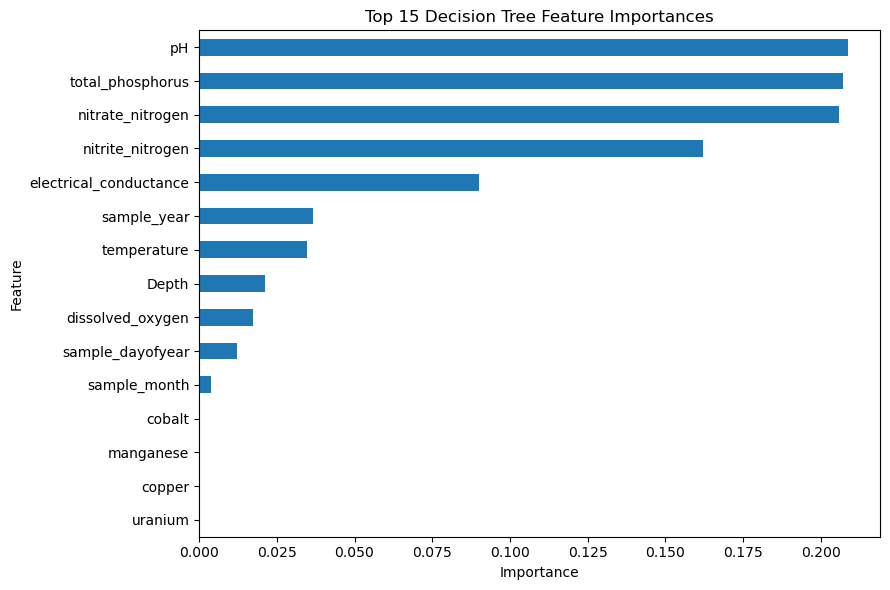

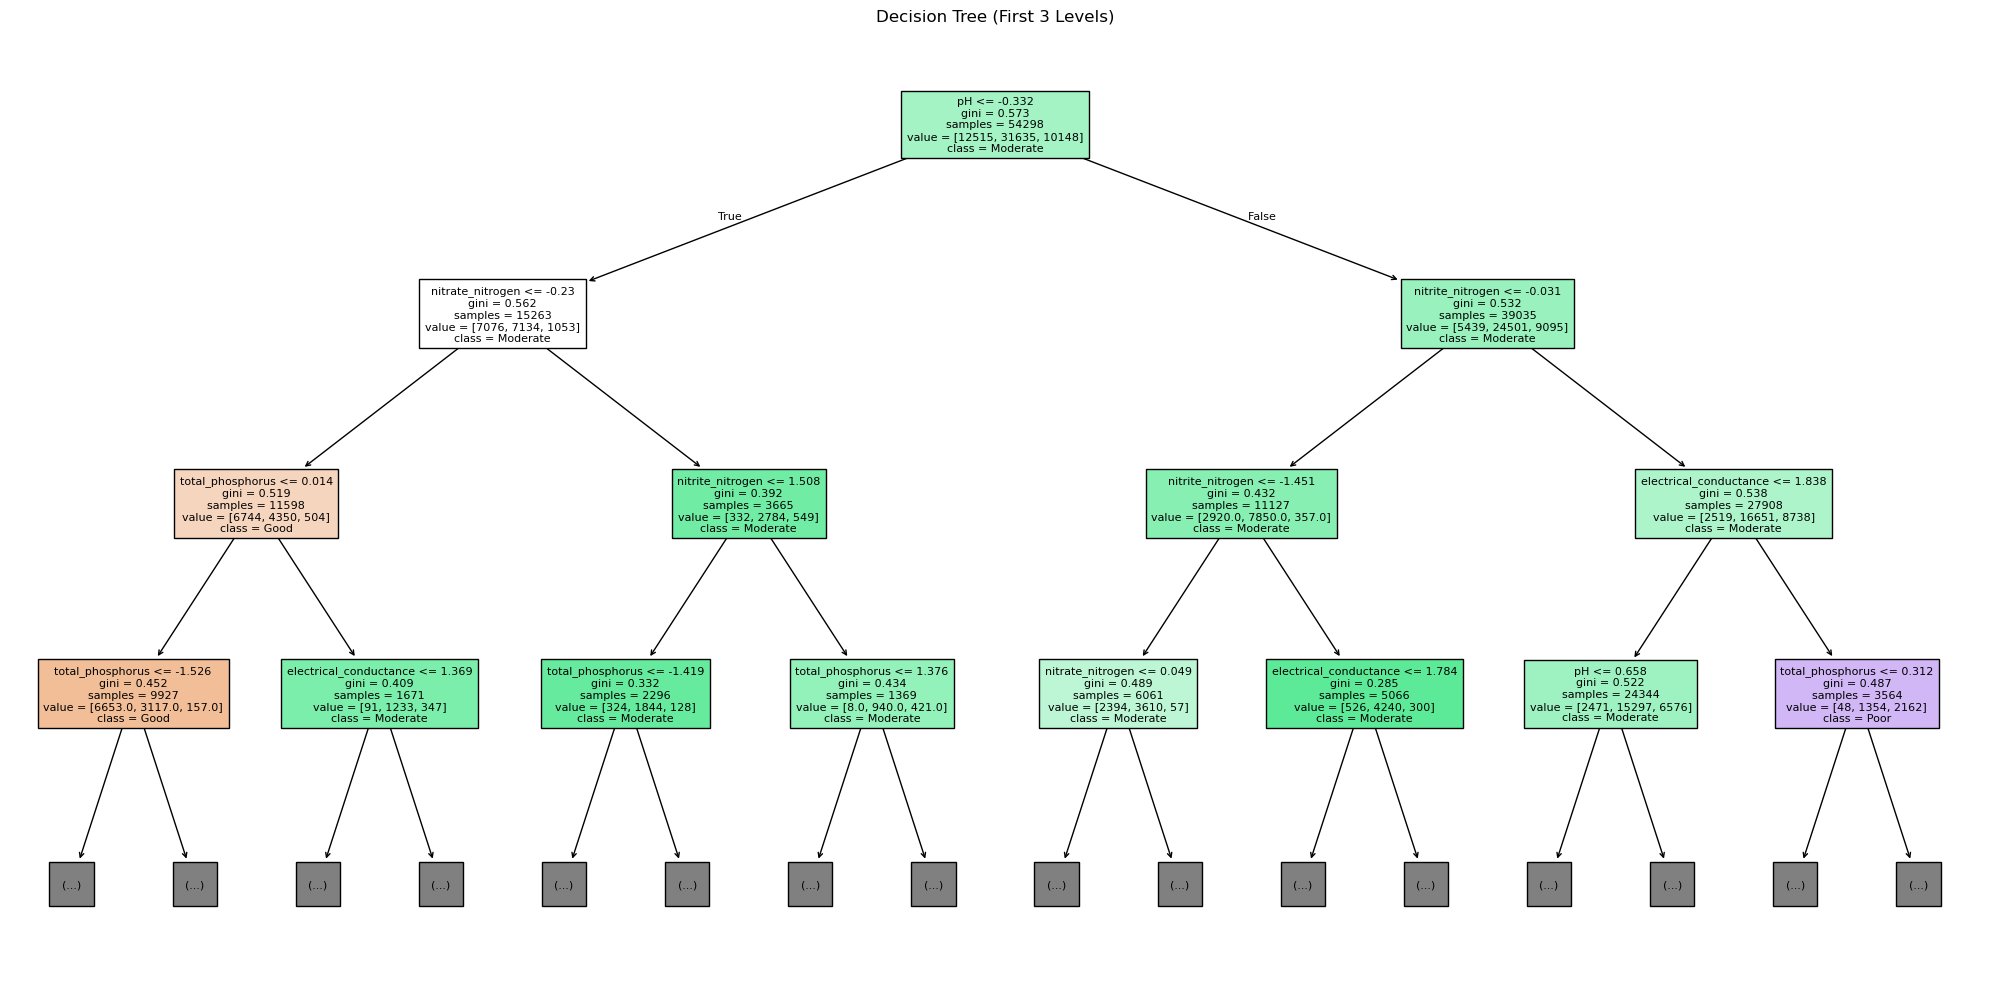

In [27]:
dt_best = dt_search.best_estimator_
feature_names = X_train.columns
importance = pd.Series(
    dt_best.named_steps["model"].feature_importances_,
    index=feature_names
).sort_values(ascending=False).head(15)

plt.figure(figsize=(9, 6))
importance.sort_values().plot(kind="barh")
plt.title("Top 15 Decision Tree Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

plt.figure(figsize=(20, 10))
plot_tree(
    dt_best.named_steps["model"],
    feature_names=feature_names,
    class_names=class_names,
    max_depth=3,
    filled=True,
    fontsize=8
)
plt.title("Decision Tree (First 3 Levels)")
plt.tight_layout()
plt.show()

## 21. Save Outputs

The final trained model and important result tables are saved so that the work can be reused later.

Saving the model means we do not have to train it again every time we want to use it for prediction.

In [28]:
os.makedirs("../models", exist_ok=True)
os.makedirs("../outputs", exist_ok=True)

joblib.dump(final_model, "../models/final_classification_model.pkl")
joblib.dump(label_encoder, "../models/target_label_encoder.pkl")

comparison_df.to_csv("../outputs/classification_comparison.csv", index=False)
tuned_results_df.to_csv("../outputs/tuned_classification_results.csv", index=False)
cv_results_df.to_csv("../outputs/5fold_cv_results.csv", index=False)

print("Saved:")
print("- ../models/final_classification_model.pkl")
print("- ../models/target_label_encoder.pkl")
print("- ../outputs/classification_comparison.csv")
print("- ../outputs/tuned_classification_results.csv")
print("- ../outputs/5fold_cv_results.csv")

Saved:
- ../models/final_classification_model.pkl
- ../models/target_label_encoder.pkl
- ../outputs/classification_comparison.csv
- ../outputs/tuned_classification_results.csv
- ../outputs/5fold_cv_results.csv


## 22. Conclusion

In this project, the complete available dataset is prepared and used for water-quality classification.

Five required Classification Part A algorithms are trained and compared:

1. Logistic Regression
2. K-Nearest Neighbors
3. Gaussian Naive Bayes
4. Decision Tree Classifier
5. Support Vector Machine

The models are evaluated using standard classification metrics, confusion matrices, and multiclass ROC-AUC. Selected models are tuned and checked using 5-fold cross-validation on the training data.

The final model is selected using the training-set cross-validation results, while the test set is kept for final performance reporting.